In [89]:
pip install pandas numpy scikit-learn matplotlib seaborn


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

In [91]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
df = pd.read_csv(url)

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [92]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [93]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [95]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=3000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr_scaled = lr_pipeline.predict(X_test)

print("Scaled Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr_scaled))

print(classification_report(y_test, y_pred_lr_scaled))

Scaled Logistic Regression Accuracy: 0.745
              precision    recall  f1-score   support

           0       0.61      0.37      0.46        59
           1       0.77      0.90      0.83       141

    accuracy                           0.74       200
   macro avg       0.69      0.64      0.65       200
weighted avg       0.73      0.74      0.72       200



In [96]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.70      0.39      0.50        59
           1       0.78      0.93      0.85       141

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200



In [97]:
print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print("Scaled Logistic Regression ROC-AUC:",
      roc_auc_score(y_test,
      lr_pipeline.predict_proba(X_test)[:,1]))

Logistic Regression ROC-AUC: 0.7529751172015867
Random Forest ROC-AUC: 0.8030412309171776
Scaled Logistic Regression ROC-AUC: 0.765115999519173


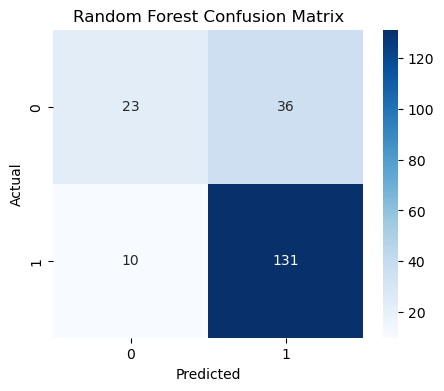

In [98]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [99]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned RF Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("Tuned RF ROC-AUC:",
      roc_auc_score(y_test,
      best_rf.predict_proba(X_test)[:,1]))

Tuned RF Accuracy: 0.765
Tuned RF ROC-AUC: 0.8037023680730857


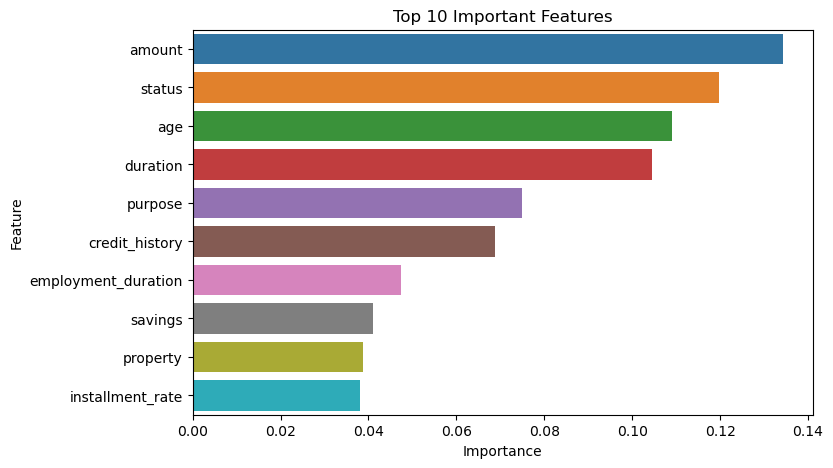

In [100]:
importances = best_rf.feature_importances_
features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [101]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.725
              precision    recall  f1-score   support

           0       0.53      0.63      0.57        59
           1       0.83      0.77      0.80       141

    accuracy                           0.72       200
   macro avg       0.68      0.70      0.69       200
weighted avg       0.74      0.72      0.73       200



In [102]:
dt_controlled = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_controlled.fit(X_train, y_train)

y_pred_dt_ctrl = dt_controlled.predict(X_test)

print("Controlled DT Accuracy:",
      accuracy_score(y_test, y_pred_dt_ctrl))

print(classification_report(y_test, y_pred_dt_ctrl))

Controlled DT Accuracy: 0.685
              precision    recall  f1-score   support

           0       0.46      0.41      0.43        59
           1       0.76      0.80      0.78       141

    accuracy                           0.69       200
   macro avg       0.61      0.60      0.61       200
weighted avg       0.67      0.69      0.68       200



In [103]:
print("Decision Tree ROC-AUC:",
      roc_auc_score(y_test,
      dt_controlled.predict_proba(X_test)[:,1]))

Decision Tree ROC-AUC: 0.690948431301839


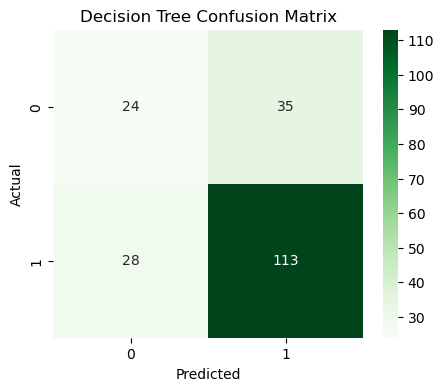

In [104]:
cm_dt = confusion_matrix(y_test, y_pred_dt_ctrl)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [105]:
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc'
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_best_dt = best_dt.predict(X_test)

print("Tuned Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_best_dt))

print("Tuned Decision Tree ROC-AUC:",
      roc_auc_score(y_test,
      best_dt.predict_proba(X_test)[:,1]))

Tuned Decision Tree Accuracy: 0.745
Tuned Decision Tree ROC-AUC: 0.7750330568577954


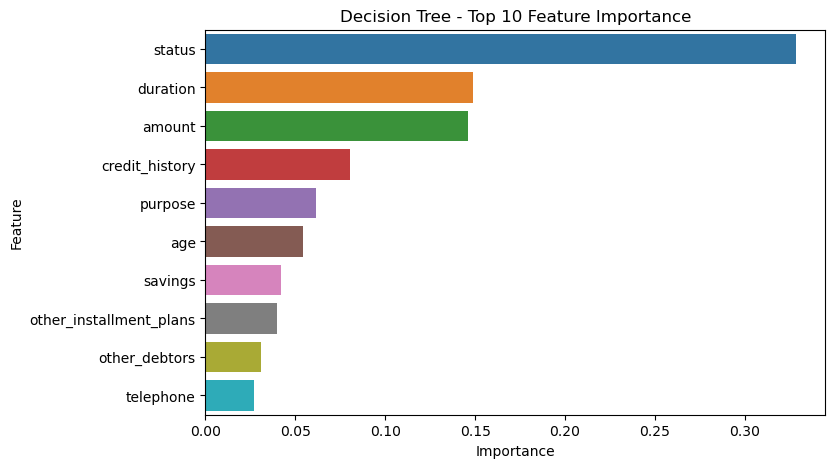

In [106]:
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=dt_importance.head(10))
plt.title("Decision Tree - Top 10 Feature Importance")
plt.show()

In [107]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_scaled),
        accuracy_score(y_test, y_pred_best_dt),
        accuracy_score(y_test, y_pred_best)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
    ]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.745,0.765116
1,Decision Tree,0.745,0.775033
2,Random Forest,0.765,0.803702


In [108]:
df.isnull().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [109]:
df = df.dropna()

In [110]:
df = df.dropna()

In [111]:
y.value_counts()

1    700
0    300
Name: credit_risk, dtype: int64

In [112]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

Text(0.5, 1.0, 'ROC Curve')

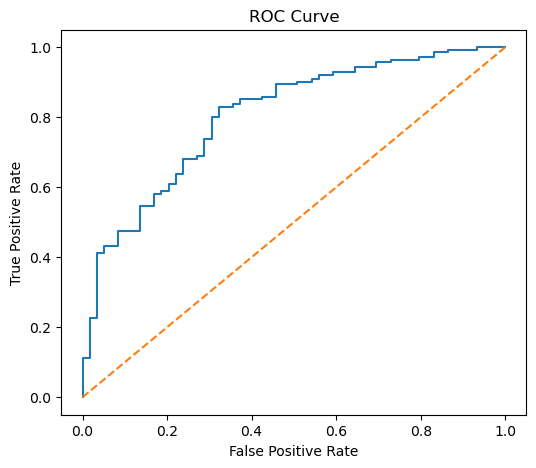

In [113]:
from sklearn.metrics import roc_curve

rf_probs = best_rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

In [114]:
from sklearn.metrics import roc_curve, auc

In [115]:
# Logistic Regression (scaled pipeline)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# Decision Tree (best tuned)
dt_probs = best_dt.predict_proba(X_test)[:, 1]

# Random Forest (best tuned)
rf_probs = best_rf.predict_proba(X_test)[:, 1]

In [116]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

In [117]:
lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

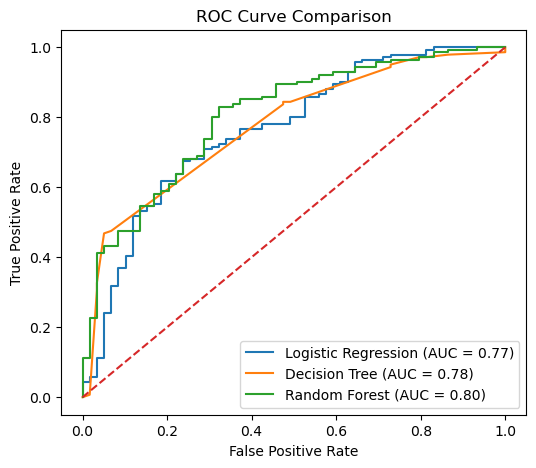

In [118]:
plt.figure(figsize=(6,5))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')

# Random guess line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [119]:
## Final Conclusion

# In this project, multiple machine learning models were implemented to predict creditworthiness.
# Logistic Regression provided a strong baseline after feature scaling.
# Decision Tree offered interpretability with controlled depth and tuning.
# Random Forest achieved the best overall performance with the highest ROC-AUC score,
# making it the most reliable model for credit scoring.

In [120]:
# ### Best Model Selection
## Based on ROC-AUC score and overall stability,
# Random Forest Classifier was selected as the final model.
#“Random Forest combines multiple decision trees, reduces overfitting, and
#achieved the highest ROC-AUC score, making it the most reliable model for credit scoring.”